:::{admonition} Download
:class: important

Download this notebook: **{nb-download}`plot_06_calcium_imaging.ipynb`**!

:::

In [1]:
%matplotlib inline
import warnings
import jax

jax.config.update("jax_enable_x64", True)

# Ignore the first specific warning
warnings.filterwarnings(
    "ignore",
    message="plotting functions contained within `_documentation_utils` are intended for nemos's documentation.",
    category=UserWarning,
)

# Ignore the second specific warning
warnings.filterwarnings(
    "ignore",
    message="Ignoring cached namespace 'core'",
    category=UserWarning,
)

warnings.filterwarnings(
    "ignore",
    message=(
        "invalid value encountered in div "
    ),
    category=RuntimeWarning,
)

(tutorial-calcium-imaging)=
Fit Calcium Imaging
============


For the example dataset, we will be working with a recording of a freely-moving mouse imaged with a Miniscope (1-photon imaging at 30Hz using the genetically encoded calcium indicator GCaMP6f). The area recorded for this experiment is the postsubiculum - a region that is known to contain head-direction cells, or cells that fire when the animal's head is pointing in a specific direction.

The data were collected by Sofia Skromne Carrasco from the [Peyrache Lab](https://www.peyrachelab.com/).

In [2]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import pynapple as nap

import nemos as nmo

configure plots

In [3]:
plt.style.use(nmo.styles.plot_style)

## Data Streaming

Here we load the data from OSF. The data is a NWB file.

In [4]:
path = nmo.fetch.fetch_data("A0670-221213.nwb")

  0%|                                              | 0.00/75.2M [00:00<?, ?B/s]

***
## pynapple preprocessing

Now that we have the file, let's load the data. The NWB file contains multiple entries.

In [5]:
data = nap.load_file(path)
print(data)

A0670-221213
┍━━━━━━━━━━━━━━━━━━━━━━━┯━━━━━━━━━━━━━┑
│ Keys                  │ Type        │
┝━━━━━━━━━━━━━━━━━━━━━━━┿━━━━━━━━━━━━━┥
│ position_time_support │ IntervalSet │
│ RoiResponseSeries     │ TsdFrame    │
│ z                     │ Tsd         │
│ y                     │ Tsd         │
│ x                     │ Tsd         │
│ rz                    │ Tsd         │
│ ry                    │ Tsd         │
│ rx                    │ Tsd         │
┕━━━━━━━━━━━━━━━━━━━━━━━┷━━━━━━━━━━━━━┙


In the NWB file, the calcium traces are saved the RoiResponseSeries field. Let's save them in a variable called 'transients' and print it.

In [6]:
transients = data['RoiResponseSeries']
print(transients)

Time (s)          0        1         2         3         4  ...
----------  -------  -------  --------  --------  --------  -----
3.1187      0.27546  0.79973  0.16383   0.20118   0.029255  ...
3.15225     0.26665  0.86751  0.15879   0.23682   0.027189  ...
3.18585     0.25796  0.89419  0.15352   0.25074   0.036514  ...
3.2194      0.24943  0.89513  0.14812   0.25215   0.056273  ...
3.253       0.24111  0.88023  0.14898   0.24651   0.070954  ...
3.28655     0.233    0.85584  0.14858   0.23706   0.081469  ...
3.32015     0.22513  1.0996   0.14715   0.22572   0.088588  ...
...                                                         ...
1203.38945  0.20815  0.17535  0.12126   0.094461  0.87427   ...
1203.42305  0.20247  0.17243  0.11807   0.089918  1.2578    ...
1203.4566   0.19654  0.17056  0.11461   0.085079  1.62      ...
1203.4902   0.19052  0.16645  0.11096   0.080197  1.8811    ...
1203.52375  0.18449  0.16105  0.10717   0.075416  2.0599    ...
1203.55735  0.17851  0.15494  0.10331 

`transients` is a [`TsdFrame`](https://pynapple.org/generated/pynapple.TsdFrame.html). Each column contains the activity of one neuron.

The mouse was recorded for a 20 minute recording epoch as we can see from the `time_support` property of the `transients` object.

In [7]:
ep = transients.time_support
print(ep)

  index    start      end
      0   3.1187  1203.59
shape: (1, 2), time unit: sec.


There are a few different ways we can explore the data. First, let's inspect the raw calcium traces for neurons 4 and 35 for the first 250 seconds of the experiment.

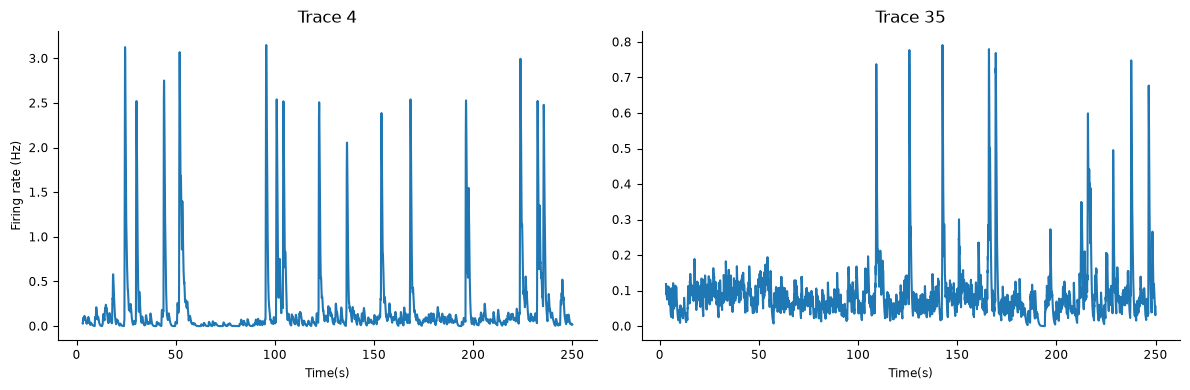

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(transients[:, 4].get(0,250))
ax[0].set_ylabel("Firing rate (Hz)")
ax[0].set_title("Trace 4")
ax[0].set_xlabel("Time(s)")
ax[1].plot(transients[:, 35].get(0,250))
ax[1].set_title("Trace 35")
ax[1].set_xlabel("Time(s)")
plt.tight_layout()

You can see that the calcium signals are both nonnegative, and noisy. One (neuron 4) has much higher SNR than the other. We cannot typically resolve individual action potentials, but instead see slow calcium fluctuations that result from an unknown underlying electrical signal (estimating the spikes from calcium traces is known as _deconvolution_ and is beyond the scope of this demo).




We can also plot tuning curves, plotting mean calcium activity as a function of head direction, using the function [`compute_tuning_curves_continuous`](https://pynapple.org/generated/pynapple.process.tuning_curves.html#pynapple.process.tuning_curves.compute_tuning_curves).
Here `data['ry']` is a [`Tsd`](https://pynapple.org/generated/pynapple.Tsd.html) that contains the angular head-direction of the animal between 0 and 2$\pi$.

In [9]:
tcurves = nap.compute_tuning_curves(transients, data['ry'], 120, feature_names=["angles"])

The function returns a pandas DataFrame. Let's plot the tuning curves for neurons 4 and 35.

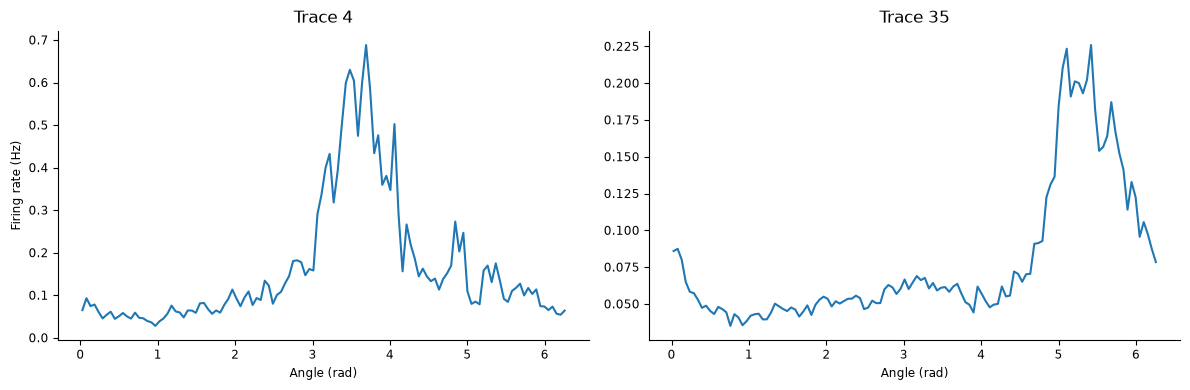

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(tcurves.angles, tcurves[4])
ax[0].set_xlabel("Angle (rad)")
ax[0].set_ylabel("Firing rate (Hz)")
ax[0].set_title("Trace 4")
ax[1].plot(tcurves.angles, tcurves[35])
ax[1].set_xlabel("Angle (rad)")
ax[1].set_title("Trace 35")
plt.tight_layout()

As a first processing step, let's bin the calcium traces to a 100ms resolution.

In [11]:
Y = transients.bin_average(0.1, ep)

We can visualize the downsampled transients for the first 50 seconds of data.

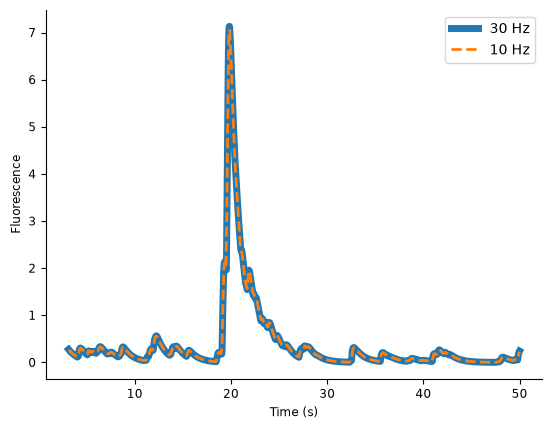

In [12]:
plt.figure()
plt.plot(transients[:,0].get(0, 50), linewidth=5, label="30 Hz")
plt.plot(Y[:,0].get(0, 50), '--', linewidth=2, label="10 Hz")
plt.xlabel("Time (s)")
plt.ylabel("Fluorescence")
plt.legend()
plt.show()

The downsampling did not destroy the fast transient dynamics, so seems fine to use. We can now move on to using NeMoS to fit a model.




## Basis instantiation

We can define a cyclic-BSpline for capturing the encoding of the heading angle, and a log-spaced raised cosine basis for the coupling filters between neurons. Note that we are not including a self-coupling (spike history) filter, because in practice we have found it results in overfitting.

We can combine the two bases.

In [13]:
heading_basis = nmo.basis.CyclicBSplineEval(n_basis_funcs=12, label="heading")
coupling_basis = nmo.basis.RaisedCosineLogConv(3, window_size=10, label="coupling")

Let's combine both basis into a single additive element.

In [14]:
basis = heading_basis + coupling_basis
basis

,label,'(heading + coupling)'
,heading__bounds,None
,heading__fill_value,nan
,heading__label,'heading'
,heading__n_basis_funcs,12
,heading__order,4
,heading,"'heading': Cy...s=12, order=4)"
,coupling__conv_kwargs,{}
,coupling__enforce_decay_to_zero,True
,coupling__label,'coupling'
,coupling__n_basis_funcs,3


## Gamma GLM

Until now, we have been modeling spike trains, and have used a Poisson distribution for the observation model. With calcium traces, things are quite different: we no longer have counts but continuous signals, so the Poisson assumption is no longer appropriate. A Gaussian model is also not ideal since the calcium traces are non-negative. To satisfy these constraints, we will use a Gamma distribution from NeMoS with a soft-plus non linearity.
:::{admonition} Non-linearity
:class: note

Different option are possible. With a soft-plus we are assuming an "additive" effect of the predictors, while an exponential non-linearity assumes multiplicative effects. Deciding which firing rate model works best is an empirical question. You can fit different configurations to see which one capture best the neural activity.
:::

In [15]:
gamma_model = nmo.glm.GLM(
    regularizer="Ridge",
    regularizer_strength=0.02,
    observation_model="Gamma",
    inverse_link_function=jax.nn.softplus,
)

We select one neuron to fit later, so remove it from the list of predictors

In [16]:
neu = 4
selected_neurons = jnp.hstack(
    (jnp.arange(0, neu), jnp.arange(neu+1, Y.shape[1]))
)

print(selected_neurons)

[ 0  1  2  3  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64]


We need to bring the head-direction of the animal to the same size as the transients matrix.
We can use the function [`bin_average`](https://pynapple.org/generated/pynapple.Tsd.bin_average.html) of pynapple. Notice how we pass the parameter `ep`
that is the `time_support` of the transients.

In [17]:
head_direction = data['ry'].bin_average(0.1, ep)

Let's check that `head_direction` and `Y` are of the same size.

In [18]:
print(head_direction.shape)
print(Y.shape)

(12005,)
(12005, 65)


## Design matrix

We can now create the design matrix by combining the head-direction of the animal and the activity of all other neurons.

In [19]:
X = basis.compute_features(head_direction, Y[:, selected_neurons])

/home/jenkins/agent/workspace/CCN_nemos_PR-597/venv/lib/python3.12/site-packages/pynapple/core/utils.py:198: UserWarning: Converting 'd' to numpy.array. The provided array was of type 'ArrayImpl'.
  warnings.warn(


```{info}

In the absence of regularization, a GLM with an intercept term would be [non identifiable](https://en.wikipedia.org/wiki/Identifiability), since the Cyclic-BSpline always sums to one over the basis functions. You can enforce a full rank by dropping the liearly dependent columns. We provide the [`identifiability_constraint` module](~nemos.identifiability_constraints.apply_identifiability_constraints) to automate the procedure.
```

## Train & test set

Let's create a train epoch and a test epoch to fit and test the models. Since `X` is a pynapple time series, we can create [`IntervalSet`](https://pynapple.org/generated/pynapple.IntervalSet.html) objects to restrict them into a train set and test set.

In [20]:
train_ep = nap.IntervalSet(start=X.time_support.start, end=X.time_support.get_intervals_center().t)
test_ep = X.time_support.set_diff(train_ep) # Removing the train_ep from time_support

print(train_ep)
print(test_ep)

  index    start      end
      0   3.1187  603.355
shape: (1, 2), time unit: sec.
  index    start      end
      0  603.355  1203.59
shape: (1, 2), time unit: sec.


We can now restrict the `X` and `Y` to create our train set and test set.

In [21]:
Xtrain = X.restrict(train_ep)
Ytrain = Y.restrict(train_ep)

Xtest = X.restrict(test_ep)
Ytest = Y.restrict(test_ep)

## Model fitting

It's time to fit the model on the data from the neuron we left out.

In [22]:
gamma_model.fit(Xtrain, Ytrain[:, neu])

,observation_model,GammaObservations()
,inverse_link_function,<PjitFunction...7f8b34b336a0>>
,regularizer,Ridge()
,regularizer_strength,0.02
,fix_params,"(None, ...)"
,solver_name,'Newton'
,solver_kwargs,{}
,fit_intercept,True
Name,Type,Value
aux_,NoneType,None
coef_,"ArrayImpl[float64](204,)",Array([-3.927...dtype=float64)


## Model comparison

We can compare the Gamma GLM to a standard Gaussian GLM. Nemos implements Gaussian GLMs as well.

In [23]:
gaussian_model = nmo.glm.GLM(
    observation_model="Gaussian",
    regularizer="Ridge",
    regularizer_strength=0.02,
)

gaussian_model.fit(Xtrain, Ytrain[:, neu])

,observation_model,GaussianObservations()
,inverse_link_function,<function <la...x7f8af5f41260>
,regularizer,Ridge()
,regularizer_strength,0.02
,fix_params,"(None, ...)"
,solver_name,'Newton'
,solver_kwargs,{}
,fit_intercept,True
Name,Type,Value
aux_,NoneType,None
coef_,"ArrayImpl[float64](204,)",Array([-6.120...dtype=float64)


We now have 2 models we can compare. Let's predict the activity of the neuron during the test epoch.

In [24]:
yp = gamma_model.predict(Xtest)
ylreg = gaussian_model.predict(Xtest)

/home/jenkins/agent/workspace/CCN_nemos_PR-597/venv/lib/python3.12/site-packages/pynapple/core/utils.py:198: UserWarning: Converting 'd' to numpy.array. The provided array was of type 'ArrayImpl'.
  warnings.warn(


Let's plot the predicted activity for the first 60 seconds of data.

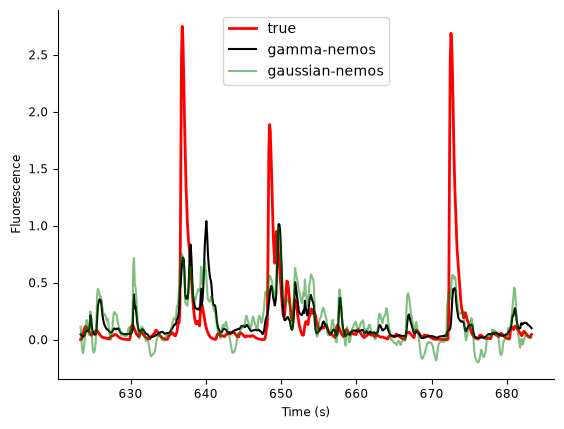

In [25]:
# mkdocs_gallery_thumbnail_number = 3

ep_to_plot = nap.IntervalSet(test_ep.start+20, test_ep.start+80)

plt.figure()
plt.plot(Ytest[:,neu].restrict(ep_to_plot), "r", label="true", linewidth=2)
plt.plot(yp.restrict(ep_to_plot), "k", label="gamma-nemos", alpha=1)
plt.plot(ylreg.restrict(ep_to_plot), "g", label="gaussian-nemos", alpha=0.5)
plt.legend(loc='best')
plt.xlabel("Time (s)")
plt.ylabel("Fluorescence")
plt.show()

While there is some variability in the fit for both models, one advantage of the gamma distribution is clear: the nonnegativity
constraint is followed with the data.
This is required for using GLMs to predict the firing rate, which must be positive, in response to simulated inputs.
See Peyrache et al. 2018[$^{[1]}$](#ref-1) for an example of simulating activity with a GLM.

Another way to compare models is to compute tuning curves. Here we use the function [`compute_tuning_curves`](https://pynapple.org/generated/pynapple.process.tuning_curves.html#pynapple.process.tuning_curves.compute_tuning_curves) from pynapple.

In [26]:
real_tcurves = nap.compute_tuning_curves(transients, data['ry'], 120, epochs=test_ep, feature_names=["hd"])
gamma_tcurves = nap.compute_tuning_curves(yp, data['ry'], 120, epochs=test_ep, feature_names=["hd"])
linreg_tcurves = nap.compute_tuning_curves(ylreg, data['ry'], 120, epochs=test_ep, feature_names=["hd"])

Let's plot them.

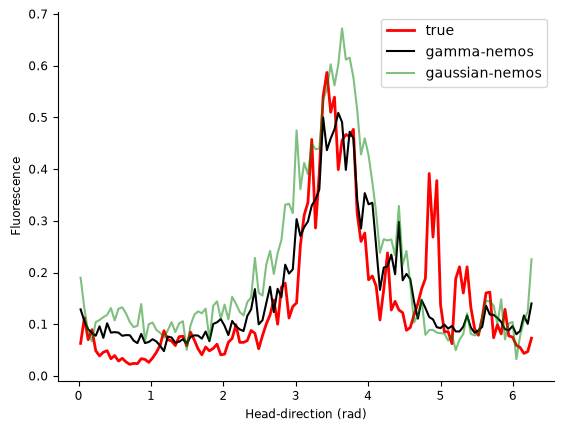

In [27]:
fig = plt.figure()
plt.plot(real_tcurves.hd, real_tcurves.sel(unit=neu), "r", label="true", linewidth=2)
plt.plot(gamma_tcurves.hd, gamma_tcurves[0], "k", label="gamma-nemos", alpha=1)
plt.plot(linreg_tcurves.hd, linreg_tcurves[0], "g", label="gaussian-nemos", alpha=0.5)
plt.legend(loc='best')
plt.ylabel("Fluorescence")
plt.xlabel("Head-direction (rad)")
plt.show()

In [28]:
# save image for thumbnail
from pathlib import Path
import os

root = os.environ.get("READTHEDOCS_OUTPUT")
if root:
   path = Path(root) / "html/_static/thumbnails/tutorials"
# if local store in assets
else:
   path = Path("../_build/html/_static/thumbnails/tutorials")

# make sure the folder exists if run from build
if root or Path("../assets/stylesheets").exists():
   path.mkdir(parents=True, exist_ok=True)

if path.exists():
  fig.savefig(path / "plot_06_calcium_imaging.svg")

:::{admonition} Gamma-GLM for Calcium Imaging Analysis
:class: note

Using Gamma-GLMs for fitting calcium imaging data is still in early stages, and hasn't been through
the levels of review and validation that they have for fitting spike data. Users should consider
this a relatively unexplored territory, and we hope that we hope that NeMoS will help researchers
explore this new space of models.
:::

## References

[1] <span id="ref-1"><a href="https://doi.org/10.1038/s41467-017-01908-3">Peyrache, A., Schieferstein, N. & Buzsáki, G. Transformation of the head-direction signal into a spatial code. Nat Commun 8, 1752 (2017). https://doi.org/10.1038/s41467-017-01908-3</a></span>